In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

print(f"✅ TensorFlow version: {tf.__version__}")

2026-05-21 01:09:06.509213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779325746.898964      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779325747.008895      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779325748.039219      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779325748.039259      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779325748.039261      23 computation_placer.cc:177] computation placer alr

✅ TensorFlow version: 2.19.0


In [2]:
# ==========================================
# 1. CẤU HÌNH (CONFIG)
# ==========================================
class TrainConfig:
    # Đường dẫn
    PROCESSED_DIR = '/kaggle/input/datasets/aresusayhi/vsl-vietnamese-sign-languages/Processed'
    MODEL_SAVE_PATH = 'models/vsl_bilstm_model.h5'
    
    # Tham số dữ liệu đầu vào
    FRAMES = 60
    FEATURES = 201
    
    # Tham số huấn luyện (Theo đúng mục 3.3 trong báo cáo)
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 1e-3

print("✅ Đã thiết lập Cấu hình Huấn luyện.")

✅ Đã thiết lập Cấu hình Huấn luyện.


In [ ]:

class VSLDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_dir, batch_size=32, shuffle=True):
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        # Lấy danh sách các nhãn (classes) từ tên thư mục
        self.classes = sorted(os.listdir(data_dir))
        self.num_classes = len(self.classes)
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        # Quét toàn bộ đường dẫn file .npz
        self.file_paths = []
        self.labels = []
        for cls_name in self.classes:
            cls_dir = os.path.join(data_dir, cls_name)
            if not os.path.isdir(cls_dir): continue
            
            for file_name in os.listdir(cls_dir):
                if file_name.endswith('.npz'):
                    self.file_paths.append(os.path.join(cls_dir, file_name))
                    self.labels.append(self.class_to_idx[cls_name])
                    
        self.indexes = np.arange(len(self.file_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        """Trả về số lượng batch trong 1 epoch"""
        return int(np.floor(len(self.file_paths) / self.batch_size))

    def __getitem__(self, index):
        """Tạo ra 1 lô (batch) dữ liệu"""
        # Lấy ra các index cho batch hiện tại
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        
        # Khởi tạo mảng trống cho X và y
        X = np.empty((self.batch_size, TrainConfig.FRAMES, TrainConfig.FEATURES))
        y = np.empty((self.batch_size), dtype=int)
        
        for i, idx in enumerate(batch_indexes):
            file_path = self.file_paths[idx]
            
            # Load file .npz
            npz_file = np.load(file_path)
            
            # LẤY ĐÚNG TÊN MẢNG: 'sequence'
            X[i,] = npz_file['sequence']
            
            # Lấy nhãn dựa trên thư mục (theo logic cũ của bạn)
            y[i] = self.labels[idx]
            
        return X, y

    def on_epoch_end(self):
        """Xáo trộn dữ liệu sau mỗi epoch"""
        if self.shuffle:
            np.random.shuffle(self.indexes)

print("✅ Đã khởi tạo lớp VSLDataGenerator.")

✅ Đã khởi tạo lớp VSLDataGenerator.


In [4]:
# ==========================================
# 3. KIẾN TRÚC MÔ HÌNH (Theo Bảng 1 của báo cáo)
# ==========================================
def build_vsl_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),
        
        # Khối BiLSTM 1
        Bidirectional(LSTM(256, return_sequences=True, dropout=0.4)),
        BatchNormalization(),
        
        # Khối BiLSTM 2
        Bidirectional(LSTM(256, return_sequences=True, dropout=0.4)),
        BatchNormalization(),
        
        # Khối BiLSTM 3
        Bidirectional(LSTM(256, return_sequences=False, dropout=0.4)),
        BatchNormalization(),
        
        # Lớp Dense 1
        Dense(512, activation='relu'),
        Dropout(0.4),
        BatchNormalization(),
        
        # Lớp Dense 2
        Dense(256, activation='relu'),
        Dropout(0.4),
        BatchNormalization(),
        
        # Lớp Output
        Dense(num_classes, activation='softmax')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=TrainConfig.LEARNING_RATE)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("✅ Đã định nghĩa hàm build_vsl_model.")

✅ Đã định nghĩa hàm build_vsl_model.


In [5]:
def plot_history(history):
    """Vẽ biểu đồ quá trình huấn luyện (giống Hình 3 trong báo cáo)"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Biểu đồ Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='lower right')
    
    # Biểu đồ Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper right')
    
    plt.savefig('training_history.png')
    plt.show()

print("✅ Đã định nghĩa hàm plot_history.")

✅ Đã định nghĩa hàm plot_history.


Đang chuẩn bị dữ liệu...
🎯 Nhận diện tổng cộng: 3315 nhãn (từ vựng).
🚀 Số lượng batch huấn luyện: 4531 batches/epoch.


I0000 00:00:1779325845.269859      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779325845.272618      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 512)        │       937,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 60, 512)        │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 512)            │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3315)           │       851,955 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,342,963 (20.38 MB)

...

4531/4531 ━━━━━━━━━━━━━━━━━━━━ 235s 52ms/step - accuracy: 0.8118 - loss: 0.6010 - val_accuracy: 0.9501 - val_loss: 0.1613 - learning_rate: 0.0010
Epoch 20/30
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8208 - loss: 0.5756
Epoch 20: val_accuracy did not improve from 0.95014
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 236s 52ms/step - accuracy: 0.8208 - loss: 0.5756 - val_accuracy: 0.9494 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 21/30
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8283 - loss: 0.5472
Epoch 21: val_accuracy did not improve from 0.95014
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 228s 50ms/step - accuracy: 0.8283 - loss: 0.5472 - val_accuracy: 0.9499 - val_loss: 0.1534 - learning_rate: 0.0010
Epoch 22/30
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8349 - loss: 0.5231
Epoch 22: val_accuracy improved from 0.95014 to 0.95789, saving model to models/vsl_bilstm_model.h5


4531/4531 ━━━━━━━━━━━━━━━━━━━━ 229s 51ms/step - accuracy: 0.8349 - loss: 0.5230 - val_accuracy: 0.9579 - val_loss: 0.1378 - learning_rate: 0.0010
Epoch 23/30
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8442 - loss: 0.4942
Epoch 23: val_accuracy did not improve from 0.95789
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 230s 51ms/step - accuracy: 0.8442 - loss: 0.4942 - val_accuracy: 0.9555 - val_loss: 0.1318 - learning_rate: 0.0010
Epoch 24/30
4530/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8500 - loss: 0.4773
Epoch 24: val_accuracy improved from 0.95789 to 0.96557, saving model to models/vsl_bilstm_model.h5


4531/4531 ━━━━━━━━━━━━━━━━━━━━ 235s 52ms/step - accuracy: 0.8500 - loss: 0.4773 - val_accuracy: 0.9656 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 25/30
4530/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8581 - loss: 0.4502
Epoch 25: val_accuracy improved from 0.96557 to 0.97031, saving model to models/vsl_bilstm_model.h5


4531/4531 ━━━━━━━━━━━━━━━━━━━━ 237s 52ms/step - accuracy: 0.8581 - loss: 0.4502 - val_accuracy: 0.9703 - val_loss: 0.1026 - learning_rate: 0.0010
Epoch 26/30
4530/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8619 - loss: 0.4353
Epoch 26: val_accuracy did not improve from 0.97031
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 241s 53ms/step - accuracy: 0.8619 - loss: 0.4353 - val_accuracy: 0.9637 - val_loss: 0.1122 - learning_rate: 0.0010
Epoch 27/30
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8636 - loss: 0.4324
Epoch 27: val_accuracy did not improve from 0.97031
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 239s 53ms/step - accuracy: 0.8636 - loss: 0.4324 - val_accuracy: 0.9586 - val_loss: 0.1250 - learning_rate: 0.0010
Epoch 28/30
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8713 - loss: 0.4051
Epoch 28: val_accuracy did not improve from 0.97031
4531/4531 ━━━━━━━━━━━━━━━━━━━━ 257s 57ms/step - accuracy: 0.8713 - loss: 0.4051 - val_accuracy: 0.9673 - val_loss: 0.0997 - learning_rat

4531/4531 ━━━━━━━━━━━━━━━━━━━━ 241s 53ms/step - accuracy: 0.8798 - loss: 0.3845 - val_accuracy: 0.9725 - val_loss: 0.0851 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 30.

🎉 HOÀN TẤT! Mô hình tốt nhất đã được lưu tại: models/vsl_bilstm_model.h5


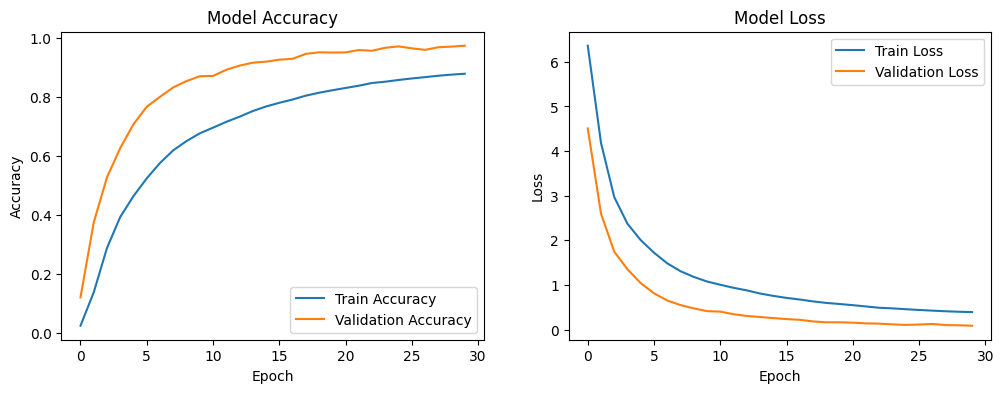

In [ ]:
# ==========================================
# 4. CHẠY HUẤN LUYỆN 
# ==========================================
train_dir = os.path.join(TrainConfig.PROCESSED_DIR, 'train')
val_dir = os.path.join(TrainConfig.PROCESSED_DIR, 'val')

if not os.path.exists(train_dir):
    print(f"❌ Không tìm thấy thư mục {train_dir}. Vui lòng kiểm tra lại quá trình tiền xử lý.")
else:
    # 1. Khởi tạo Trình sinh dữ liệu (Generator)
    print("Đang chuẩn bị dữ liệu...")
    train_gen = VSLDataGenerator(train_dir, batch_size=TrainConfig.BATCH_SIZE, shuffle=True)
    val_gen = VSLDataGenerator(val_dir, batch_size=TrainConfig.BATCH_SIZE, shuffle=False)
    
    num_classes = train_gen.num_classes
    print(f"🎯 Nhận diện tổng cộng: {num_classes} nhãn (từ vựng).")
    print(f"🚀 Số lượng batch huấn luyện: {len(train_gen)} batches/epoch.")

    # 2. Xây dựng mô hình
    model = build_vsl_model((TrainConfig.FRAMES, TrainConfig.FEATURES), num_classes)
    model.summary()

    # 3. Cài đặt các Callbacks
    os.makedirs('models', exist_ok=True)
    
    # Dừng sớm nếu Validation Loss không giảm sau 10 epochs
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True,
        verbose=1
    )
    
    # Lưu lại model có Val_Accuracy cao nhất
    checkpoint = ModelCheckpoint(
        TrainConfig.MODEL_SAVE_PATH, 
        monitor='val_accuracy', 
        save_best_only=True, 
        verbose=1
    )
    
    # Giảm Learning Rate nếu Loss đứng im
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

    # 4. Tiến hành Huấn luyện
    print("\n🔥 BẮT ĐẦU HUẤN LUYỆN MODEL 🔥")
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=TrainConfig.EPOCHS,
        callbacks=[early_stopping, checkpoint, reduce_lr]
    )
    
    print(f"\n🎉 HOÀN TẤT! Mô hình tốt nhất đã được lưu tại: {TrainConfig.MODEL_SAVE_PATH}")
    
    # 5. Vẽ biểu đồ kết quả
    plot_history(history)